# Introdução

Neste documento vamos apresentar de maneira consolidada o comportamento do modelo Before.IT, que foi detalhado na parte dois.  

Estas são as principais características do modelo: 

1. **Previsão macroeconômica:** Procura reproduzir e prever ("forecasting") os principais indicadores agregados da econônomia.

2. **Calibração e verossimilhança com as estatísticas nacionais:** Implementa o modelo de acordo com as premissas da contabilidade nacional, ou seja, reproduz as mesmas entidades, impostos, relações mapeados nas estatísticas econômicas da União Europeia, calibrando estas entidades e relações para dar a maior similitude possível ao modelo. 

3. **Regras AR(1) para formação de expectativas:** Utiliza uma regra auto regressiva de ordem 1 ( AR(1) ) como forma de aprenzidado e previsão compartilhada dos agentes para os indicadores macroeconomicos, como crescimento da econômia (PIB) e inflação.

4. **Mercados com frições:** Implementa mercados com frição e aleatoriedade onde, em geral, as expectativas são "quebradas" e as variáveis de expectativas "se tornam" variáveis realizadas.

Abaixo iremos explorar cada uma dessas características com exemplos práticos a partir do código. 


## Previsão macroeconômica

O BeforeIT foi desenvolvido para produzir previsões macroeconômicas a partir das interações entre agentes heterogêneos. A ideia é prever, ao longo do tempo, os principais indicadores da econômia dos países europeus, em especial a Áustria e a Itália. 

A célula abaixo exemplifica os agregados econômicos produzidos pelo modelo. 

In [1]:
import BeforeIT as Bit
using Plots
using Random
using Printf

Random.seed!(123)

model = Bit.Model(
    Bit.AUSTRIA2010Q1.parameters,
    Bit.AUSTRIA2010Q1.initial_conditions,
);

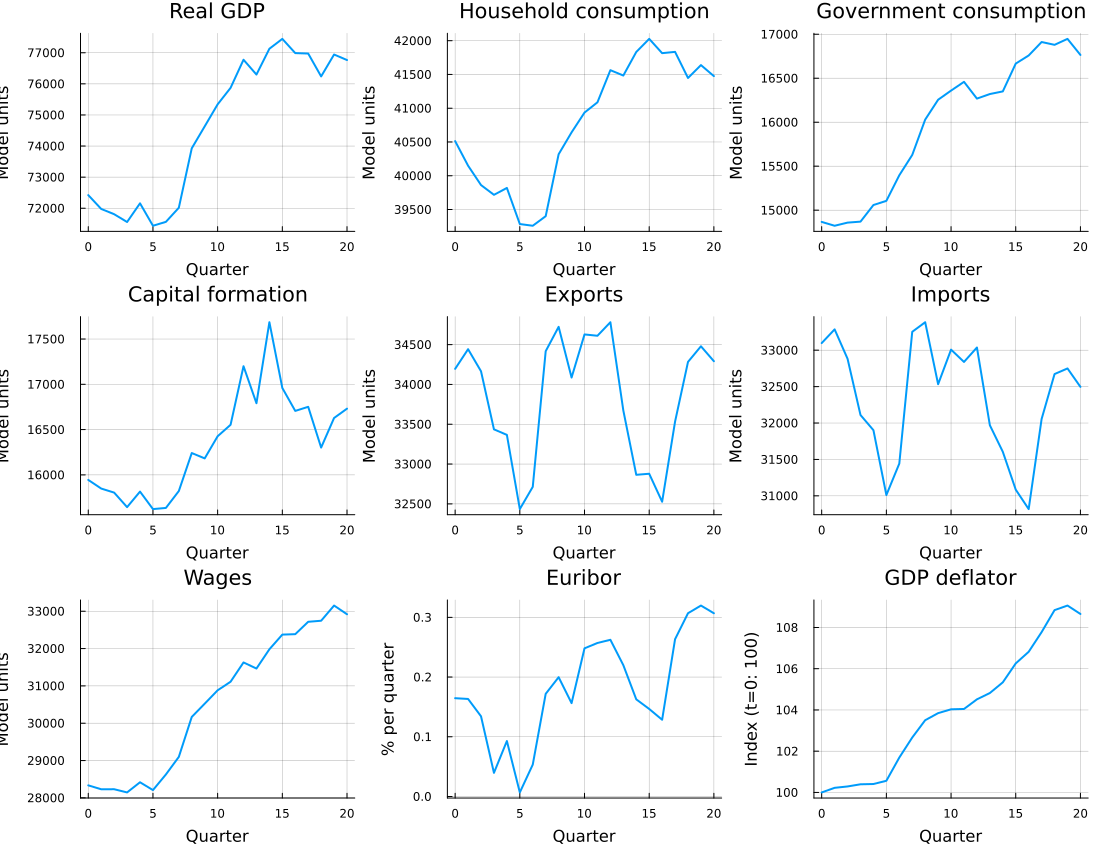

In [2]:
T = 20

@assert length(model.data.collection_time) == 1 "Execute novamente a célula de configuração antes desta simulação."
Bit.run!(model, T; parallel = false)

data = model.data
time = data.collection_time .- first(data.collection_time)
gdp_deflator = data.nominal_gdp ./ data.real_gdp

@assert length(time) == T + 1

series = [
    ("PIB real", data.real_gdp, "Unidades do modelo"),
    ("Consumo das famílias", data.real_household_consumption, "Unidades do modelo"),
    ("Consumo do governo", data.real_government_consumption, "Unidades do modelo"),
    ("Formação de capital", data.real_capitalformation, "Unidades do modelo"),
    ("Exportações", data.real_exports, "Unidades do modelo"),
    ("Importações", data.real_imports, "Unidades do modelo"),
    ("Salários", data.wages, "Unidades do modelo"),
    ("Euribor", 100 .* data.euribor, "% por trimestre"),
    ("Deflator do PIB", 100 .* gdp_deflator ./ first(gdp_deflator), "Índice (t=0: 100)"),
]

panels = [
    plot(
        time,
        values;
        title,
        xlabel = "Trimestre",
        ylabel = unit,
        linewidth = 2,
        legend = false,
        gridalpha = 0.3,
    )
    for (title, values, unit) in series
]

plot(panels...; layout = (3, 3), size = (1100, 850))

## Calibração e verossimilhança com as estatísticas nacionais

O BeforeIT combina parâmetros obtidos diretamente das contas nacionais, coeficientes estimados de séries temporais e hipóteses fixadas na calibração. O pacote fornece configurações próprias para Áustria e Itália; neste notebook usamos `Bit.AUSTRIA2010Q1`.

O conjunto de parâmetros contém escalares, vetores e matrizes. Por ser uma lista extensa, abaixo demonstramos alguns dos parâmetros importantes para o modelo

A distribuição de empresas entre os setores é armazenada em `I_s`. Os vetores `b_HH_g`, `b_CFH_g` e `b_CF_g` distribuem, respectivamente, o consumo das famílias, o investimento residencial e o investimento das empresas entre os produtos. Embora estejam relacionados à estrutura de insumo-produto, esses `b` são vetores de composição da demanda final; `a_sg` é a matriz de coeficientes de insumos intermediários. Os gráficos abaixo mostram essas distribuições.

In [3]:
using DataFrames

raw_parameters = Bit.AUSTRIA2010Q1.parameters

parameter_specs = [
    (
        symbol = "T′",
        key = "T_prime",
        field = :T_prime,
        origin = "Configuração da amostra",
        role = "Observações históricas usadas para estimar expectativas",
    ),
    (
        symbol = "τ_VAT",
        key = "tau_VAT",
        field = :tau_VAT,
        origin = "Contas nacionais",
        role = "Alíquota efetiva sobre o consumo das famílias",
    ),
    (
        symbol = "ψ",
        key = "psi",
        field = :psi,
        origin = "Contas nacionais",
        role = "Parcela da renda disponível destinada ao consumo",
    ),
    (
        symbol = "ψ_H",
        key = "psi_H",
        field = :psi_H,
        origin = "Contas nacionais",
        role = "Parcela da renda disponível destinada ao investimento residencial",
    ),
    (
        symbol = "θ_DIV",
        key = "theta_DIV",
        field = :theta_DIV,
        origin = "Contas nacionais",
        role = "Proporção dos lucros distribuída como dividendos",
    ),
    (
        symbol = "θ",
        key = "theta",
        field = :theta,
        origin = "Hipótese fixa",
        role = "Parcela da dívida pendente amortizada a cada período",
    ),
    (
        symbol = "ζ",
        key = "zeta",
        field = :zeta,
        origin = "Hipótese fixa",
        role = "Coeficiente de exigência de capital bancário",
    ),
    (
        symbol = "ζ_LTV",
        key = "zeta_LTV",
        field = :zeta_LTV,
        origin = "Hipótese fixa",
        role = "Limite da razão entre empréstimo e valor para as empresas",
    ),
]

model_values = [
    getproperty(model.prop, spec.field)
    for spec in parameter_specs
]

raw_values = [
    raw_parameters[spec.key]
    for spec in parameter_specs
]

@assert all(
    isapprox(Float64(model_value), Float64(raw_value))
    for (model_value, raw_value) in zip(model_values, raw_values)
)

parameter_examples = DataFrame(
    "Código" => ["model.prop.$(spec.field)" for spec in parameter_specs],
    "Valor" => model_values,
    "Origem" => [spec.origin for spec in parameter_specs],
    "Papel econômico" => [spec.role for spec in parameter_specs],
)

parameter_values = select(
    parameter_examples,
    "Código",
    "Valor",
    "Origem",
)

parameter_roles = select(
    parameter_examples,
    "Código",
    "Papel econômico",
)

display(parameter_values)
display(parameter_roles)

Row,Code,Value,Origin
,String,Real,String
1,model.prop.T_prime,54,Sample setting
2,model.prop.tau_VAT,0.152868,National accounts
3,model.prop.psi,0.909668,National accounts
4,model.prop.psi_H,0.071251,National accounts
5,model.prop.theta_DIV,0.785807,National accounts
6,model.prop.theta,0.05,Fixed assumption
7,model.prop.zeta,0.03,Fixed assumption
8,model.prop.zeta_LTV,0.6,Fixed assumption


Row,Code,Role
,String,String
1,model.prop.T_prime,Historical observations used to estimate expectations
2,model.prop.tau_VAT,Effective tax rate on household consumption
3,model.prop.psi,Share of disposable income allocated to consumption
4,model.prop.psi_H,Share of disposable income allocated to housing investment
5,model.prop.theta_DIV,Dividend payout ratio
6,model.prop.theta,Share of outstanding \n debt repaid each period
7,model.prop.zeta,Bank capital requirement coefficient
8,model.prop.zeta_LTV,Loan-to-value \n limit for firms


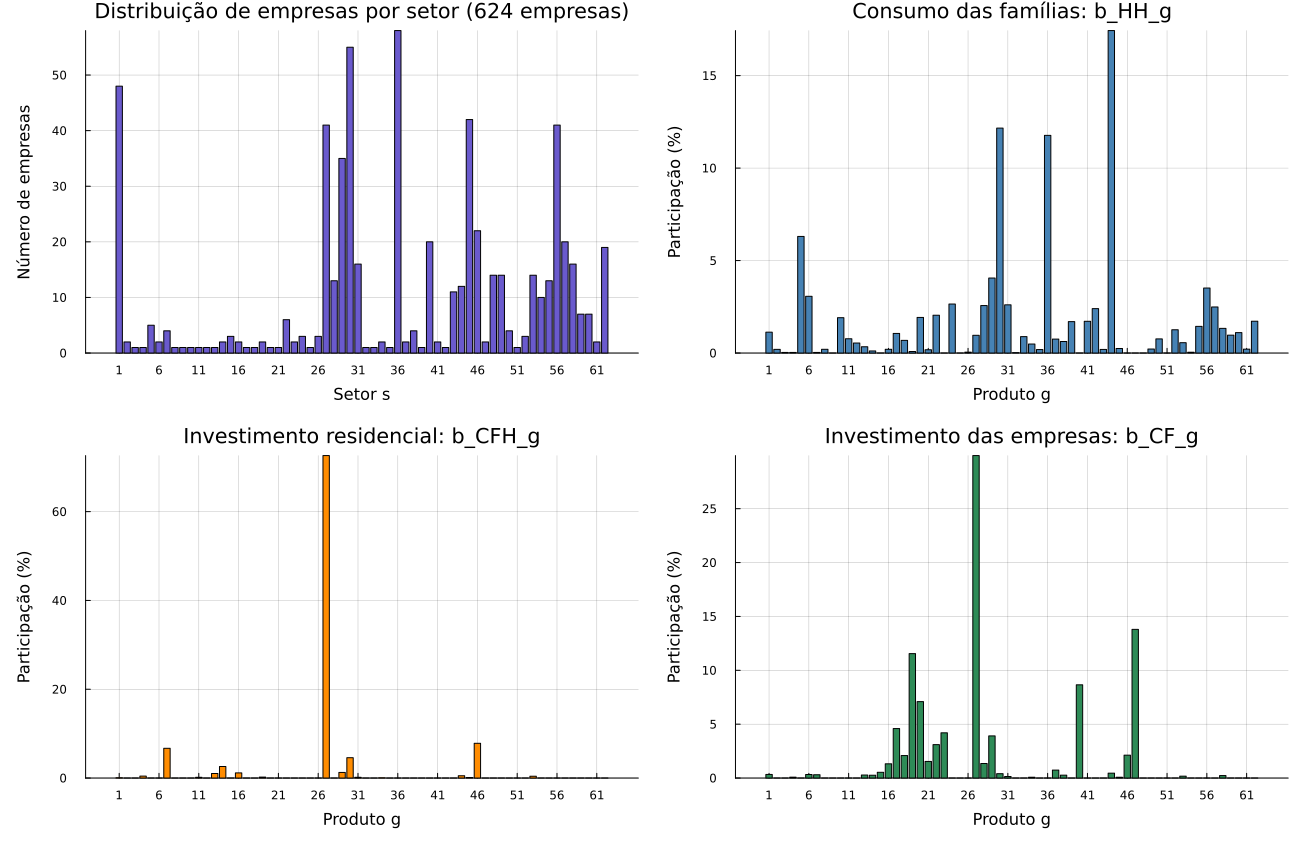

In [4]:

# Firm allocation across industries
firm_counts = model.prop.I_s
industries = eachindex(firm_counts)

# Product-composition coefficients
b_series = [
    (model.prop.b_HH_g,  "Consumo das famílias: b_HH_g", :steelblue),
    (model.prop.b_CFH_g, "Investimento residencial: b_CFH_g", :darkorange),
    (model.prop.b_CF_g,  "Investimento das empresas: b_CF_g", :seagreen),
]

n_products = length(model.prop.b_HH_g)
products = 1:n_products

# Consistency checks
@assert length(firm_counts) == n_products
@assert all(firm_counts .>= 0)
@assert all(
    isapprox(sum(values), 1.0; atol = 1.0e-10)
    for (values, _, _) in b_series
)

firm_plot = bar(
    industries,
    firm_counts;
    title = "Distribuição de empresas por setor ($(sum(firm_counts)) empresas)",
    xlabel = "Setor s",
    ylabel = "Número de empresas",
    color = :slateblue,
    legend = false,
    xticks = 1:5:n_products,
    gridalpha = 0.25,
)

b_plots = [
    bar(
        products,
        100 .* values;
        title,
        xlabel = "Produto g",
        ylabel = "Participação (%)",
        color,
        legend = false,
        xticks = 1:5:n_products,
        gridalpha = 0.25,
    )
    for (values, title, color) in b_series
]

plot(
    firm_plot,
    b_plots...;
    layout = (2, 2),
    size = (1300, 850),
    left_margin = 8Plots.mm,
    bottom_margin = 7Plots.mm,
)

## Regra autorregressiva de ordem 1

A cada passo, o modelo estima regras autorregressivas de ordem 1 para formar duas expectativas agregadas compartilhadas pelos agentes:

- PIB esperado e crescimento esperado;
- inflação esperada.


### Como funciona a regra AR(1)?

Para uma série $z_1,\ldots,z_n$, o modelo estima a regressão autorregressiva:

$$
z_t = \alpha z_{t-1} + \beta + u_t
$$

A estimação usa os pares:

$$
(z_1,z_2),\;(z_2,z_3),\ldots,(z_{n-1},z_n)
$$

que podem ser escritos como:

$$
\mathbf{y} =
\begin{bmatrix}
z_2\\
z_3\\
\vdots\\
z_n
\end{bmatrix},
\qquad
\mathbf{X} =
\begin{bmatrix}
z_1 & 1\\
z_2 & 1\\
\vdots & \vdots\\
z_{n-1} & 1
\end{bmatrix}
$$

Os valores de $\alpha$ e $\beta$ são escolhidos para minimizar a soma dos erros quadráticos:

$$
(\hat{\alpha},\hat{\beta})
=
\underset{\alpha,\beta}{\operatorname{argmin}}
\sum_{t=2}^{n}
\left(z_t-\alpha z_{t-1}-\beta\right)^2
$$

A interpretação dos parâmetros é:

- $\hat{\alpha}$ mede a persistência da série;
- $\hat{\beta}$ é o intercepto ou termo constante;
- $u_t$ é o resíduo observado, isto é, a parte da amostra que a regressão não explicou.

Quando $|\hat{\alpha}|<1$, o processo é estacionário e sua média de longo prazo é:

$$
\bar z = \frac{\hat{\beta}}{1-\hat{\alpha}}
$$

Se $|\hat{\alpha}|\geq 1$, essa média estacionária não existe.

Após a estimação, calcula-se a variância dos resíduos:

$$
\hat{\sigma}_u^2 = \operatorname{Var}(\hat{u}_t)
$$

e sorteia-se uma nova inovação para o período seguinte:

$$
\varepsilon_{n+1} \sim \mathcal{N}(0,\hat{\sigma}_u^2)
$$

A previsão seguinte é então:

$$
z_{n+1}^{e}
=
\hat{\alpha}z_n+\hat{\beta}+\varepsilon_{n+1}
$$

O termo $\hat{\alpha}z_n+\hat{\beta}$ é a esperança condicional dada a informação disponível. A soma de $\varepsilon_{n+1}$ produz uma realização estocástica da expectativa. Assim, `u_t` designa os resíduos históricos usados para estimar a incerteza, enquanto $\varepsilon_{n+1}$ designa a nova inovação sorteada.

Abaixo, utilizamos uma sequência de dados simuladas para exemplificar a aplicação prática de uma regressão AR(1). 


True alpha:      0.7000
Estimated alpha: 0.6790
True beta:       2.0000
Estimated beta:  2.0490
Residual sigma:  0.9382


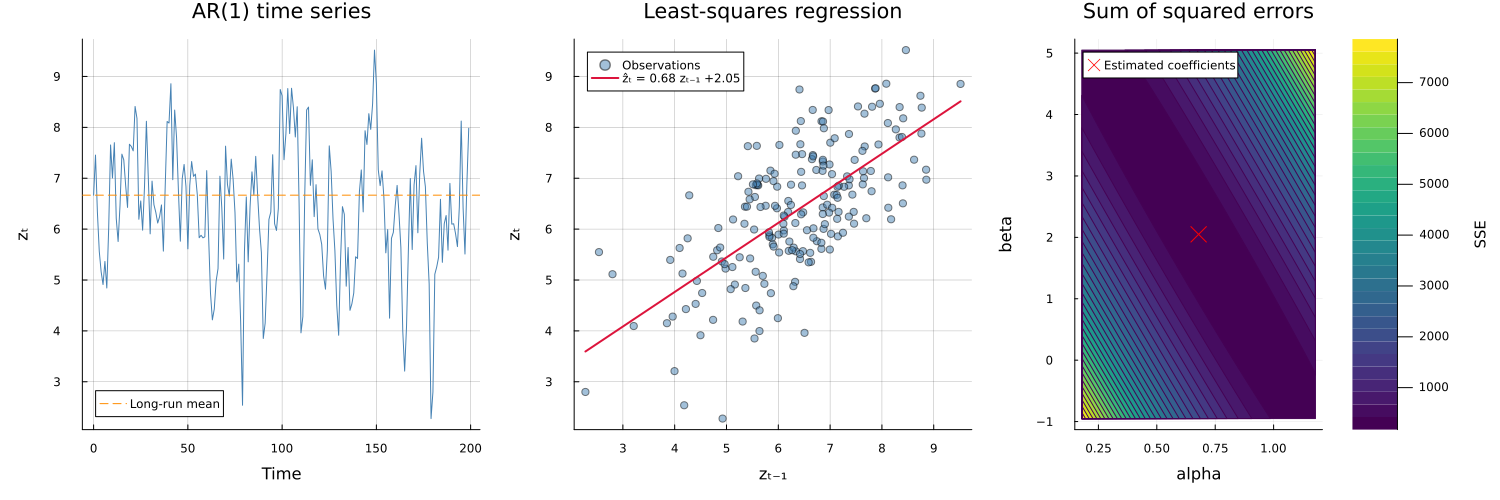

In [5]:
Random.seed!(42)

# Parameters used to generate the example
alpha_true = 0.7
beta_true = 2.0
n_observations = 200
long_run_mean = beta_true / (1 - alpha_true)

# Simulate a stationary AR(1) series
z = fill(long_run_mean, n_observations)

for t in 2:n_observations
    innovation = randn()
    z[t] = alpha_true * z[t-1] + beta_true + innovation
end

# Estimate the coefficients by least squares
lagged = z[1:end-1]
current = z[2:end]
design = hcat(lagged, ones(length(lagged)))
alpha_estimated, beta_estimated = design \ current
fitted = alpha_estimated .* lagged .+ beta_estimated

# Check the simplified calculation against the BeforeIT implementation
alpha_bit, beta_bit, sigma_bit, _ = Bit.estimate_for_calibration_script(z)
@assert isapprox(alpha_estimated, alpha_bit; atol = 1.0e-10)
@assert isapprox(beta_estimated, beta_bit; atol = 1.0e-10)

@printf("Alfa verdadeiro:  %.4f\n", alpha_true)
@printf("Alfa estimado:    %.4f\n", alpha_estimated)
@printf("Beta verdadeiro:  %.4f\n", beta_true)
@printf("Beta estimado:    %.4f\n", beta_estimated)
@printf("Sigma residual:   %.4f\n", sigma_bit)

# 1. Time series
p1 = plot(
    0:(n_observations-1), z;
    color = :steelblue,
    title = "Série temporal AR(1)",
    xlabel = "Período",
    ylabel = "zₜ",
    label = false,
    gridalpha = 0.3,
)

hline!(
    p1,
    [long_run_mean];
    color = :darkorange,
    linestyle = :dash,
    label = "Média de longo prazo",
)

# 2. Least-squares regression
order = sortperm(lagged)

p2 = scatter(
    lagged, current;
    alpha = 0.5,
    color = :steelblue,
    label = "Observações",
    title = "Regressão por mínimos quadrados",
    xlabel = "zₜ₋₁",
    ylabel = "zₜ",
    gridalpha = 0.3,
)

plot!(
    p2,
    lagged[order],
    fitted[order];
    color = :crimson,
    linewidth = 2,
    label = @sprintf(
        "ẑₜ = %.2f zₜ₋₁ %+.2f",
        alpha_estimated,
        beta_estimated,
    ),
)

# 3. Sum of squared errors
alpha_values = range(
    alpha_estimated - 0.5,
    alpha_estimated + 0.5;
    length = 120,
)

beta_values = range(
    beta_estimated - 3,
    beta_estimated + 3;
    length = 120,
)

squared_errors = [
    sum((current .- alpha .* lagged .- beta) .^ 2)
    for beta in beta_values, alpha in alpha_values
]

p3 = contourf(
    alpha_values,
    beta_values,
    squared_errors;
    levels = 30,
    color = :viridis,
    title = "Soma dos quadrados dos resíduos",
    xlabel = "alfa",
    ylabel = "beta",
    colorbar_title = "SQR",
)

scatter!(
    p3,
    [alpha_estimated],
    [beta_estimated];
    color = :red,
    marker = :x,
    markersize = 8,
    label = "Coeficientes estimados",
)

plot(
    p1, p2, p3;
    layout = (1, 3),
    size = (1500, 500),
    left_margin = 10Plots.mm,
    bottom_margin = 10Plots.mm,
    top_margin = 5Plots.mm,
)

### Expectativas do PIB e da inflação

Para o PIB, define-se:

$$
y_k = \log(Y_k)
$$

A previsão do logaritmo do PIB é:

$$
y_{s+1}^{e} = \hat{\alpha}_Y y_s + \hat{\beta}_Y + \varepsilon_{Y,s+1}
$$

Voltando ao nível e calculando o crescimento esperado:

$$
Y^{e} = \exp(y_{s+1}^{e}),
\qquad
\gamma^{e} = \frac{Y^{e}}{Y_s}-1
$$

Para a inflação, a série armazenada pelo modelo é a variação logarítmica do índice de preços:

$$
q_k = \log\left(\frac{P_k}{P_{k-1}}\right)
$$

A mesma estimação produz:

$$
q_{s+1}^{e} = \hat{\alpha}_\pi q_s + \hat{\beta}_\pi + \varepsilon_{\pi,s+1},
\qquad
\pi^{e} = \exp(q_{s+1}^{e})-1
$$

| Símbolo | Código | Significado |
|---|---|---|
| $Y^{e}$ | `model.agg.Y_e` | Nível esperado do PIB. |
| $\gamma^{e}$ | `model.agg.gamma_e` | Taxa esperada de crescimento do PIB. |
| $\pi^{e}$ | `model.agg.pi_e` | Taxa esperada de inflação. |
| $\varepsilon_{Y,s+1}$ | sorteado por `estimate` | Inovação da expectativa do PIB. |
| $\varepsilon_{\pi,s+1}$ | sorteado por `estimate` | Inovação da expectativa de inflação. |

O mecanismo é adaptativo porque, após cada passo, uma nova observação de PIB e inflação entra no histórico e os coeficientes são reestimados. Não há uma AR(1) diferente para cada agente: `Y_e`, `gamma_e` e `pi_e` são expectativas agregadas compartilhadas.

Row,Série transformada,α̂,β̂,σ̂,Último valor,Previsão condicional,Inovação ε,Previsão estocástica
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,log(PIB),0.975495,0.292319,0.0071682,11.8712,11.8726,-0.00290414,11.8697
2,log(Pₜ/Pₜ₋₁),0.250016,0.00277368,0.00416706,-0.00375566,0.00183471,-0.00336699,-0.00153229


PIB esperado: 142869.55 | crescimento esperado: -0.15% | inflação esperada: -0.15%


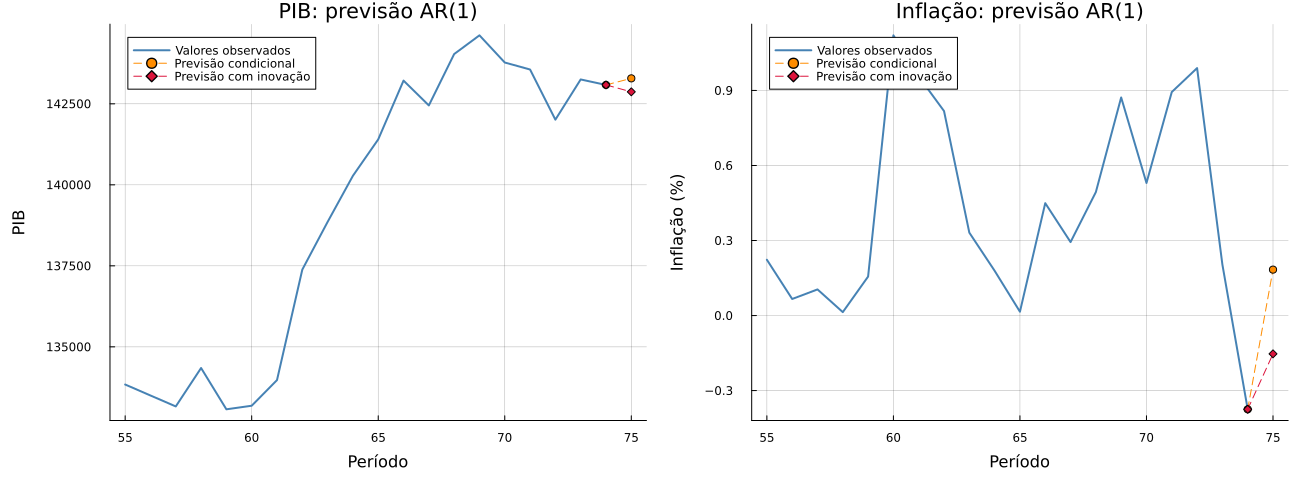

In [6]:
# Reproduce the AR(1) forecasts without changing model
last_index = model.prop.T_prime + model.agg.t - 1
gdp_history = model.agg.Y[1:last_index]
inflation_history = model.agg.pi_[1:last_index]

@assert all(gdp_history .> 0)
@assert length(inflation_history) == last_index

log_gdp = log.(gdp_history)
alpha_gdp, beta_gdp, sigma_gdp, _ = Bit.estimate_for_calibration_script(log_gdp)
alpha_inflation, beta_inflation, sigma_inflation, _ =
    Bit.estimate_for_calibration_script(inflation_history)

# A local generator keeps the simulation's random state unchanged
forecast_rng = Random.Xoshiro(2026)
gdp_innovation = sigma_gdp * randn(forecast_rng)
inflation_innovation = sigma_inflation * randn(forecast_rng)

conditional_log_gdp = alpha_gdp * last(log_gdp) + beta_gdp
stochastic_log_gdp = conditional_log_gdp + gdp_innovation
conditional_log_inflation =
    alpha_inflation * last(inflation_history) + beta_inflation
stochastic_log_inflation = conditional_log_inflation + inflation_innovation

conditional_gdp = exp(conditional_log_gdp)
expected_gdp = exp(stochastic_log_gdp)
expected_growth = expected_gdp / last(gdp_history) - 1
conditional_inflation = exp(conditional_log_inflation) - 1
expected_inflation = exp(stochastic_log_inflation) - 1

forecast_table = DataFrame(
    "Série transformada" => ["log(PIB)", "log(Pₜ/Pₜ₋₁)"],
    "α̂" => [alpha_gdp, alpha_inflation],
    "β̂" => [beta_gdp, beta_inflation],
    "σ̂" => [sigma_gdp, sigma_inflation],
    "Último valor" => [last(log_gdp), last(inflation_history)],
    "Previsão condicional" => [conditional_log_gdp, conditional_log_inflation],
    "Inovação ε" => [gdp_innovation, inflation_innovation],
    "Previsão estocástica" => [stochastic_log_gdp, stochastic_log_inflation],
)

display(forecast_table)
@printf(
    "PIB esperado: %.2f | crescimento esperado: %.2f%% | inflação esperada: %.2f%%\n",
    expected_gdp,
    100 * expected_growth,
    100 * expected_inflation,
)

# Plot only the latest observations, although estimation uses the full history
display_window = max(1, last_index - 19):last_index
forecast_index = last_index + 1

gdp_plot = plot(
    display_window,
    gdp_history[display_window];
    title = "PIB: previsão AR(1)",
    xlabel = "Período",
    ylabel = "PIB",
    color = :steelblue,
    linewidth = 2,
    label = "Valores observados",
    gridalpha = 0.3,
)

plot!(
    gdp_plot,
    [last_index, forecast_index],
    [last(gdp_history), conditional_gdp];
    color = :darkorange,
    linestyle = :dash,
    marker = :circle,
    label = "Previsão condicional",
)

plot!(
    gdp_plot,
    [last_index, forecast_index],
    [last(gdp_history), expected_gdp];
    color = :crimson,
    linestyle = :dash,
    marker = :diamond,
    label = "Previsão com inovação",
)

inflation_percent = 100 .* (exp.(inflation_history) .- 1)
inflation_plot = plot(
    display_window,
    inflation_percent[display_window];
    title = "Inflação: previsão AR(1)",
    xlabel = "Período",
    ylabel = "Inflação (%)",
    color = :steelblue,
    linewidth = 2,
    label = "Valores observados",
    gridalpha = 0.3,
)

plot!(
    inflation_plot,
    [last_index, forecast_index],
    [last(inflation_percent), 100 * conditional_inflation];
    color = :darkorange,
    linestyle = :dash,
    marker = :circle,
    label = "Previsão condicional",
)

plot!(
    inflation_plot,
    [last_index, forecast_index],
    [last(inflation_percent), 100 * expected_inflation];
    color = :crimson,
    linestyle = :dash,
    marker = :diamond,
    label = "Previsão com inovação",
)

plot(
    gdp_plot,
    inflation_plot;
    layout = (1, 2),
    size = (1300, 480),
    left_margin = 8Plots.mm,
    bottom_margin = 7Plots.mm,
)

### Inovações gaussianas na formação das expectativas

Depois de estimar a AR(1), o modelo calcula a variância dos resíduos históricos e usa seu desvio-padrão para sortear uma inovação:

$$
\varepsilon_{s+1}\sim\mathcal{N}(0,\hat{\sigma}_u^2)
$$

Os sorteios do PIB e da inflação são realizados separadamente. 


## Aplicação das expectativas

As expectativas agregadas são calculadas de maneira conjunta, antes dos agentes tomarem suas decisões, funcionando como insumos para os planos das empresas, do banco e das famílias.

### Empresas

Cada empresa projeta sua quantidade desejada a partir da demanda observada anteriormente e do crescimento esperado da economia:

$$
Q_i^{s}=Q_i^{d}(1+\gamma^{e})
$$

A inflação esperada entra na atualização do preço, juntamente com a inflação de custos específica da empresa $\pi_i^c$:

$$
P_i^{novo}=P_i(1+\pi_i^c)(1+\pi^{e})
$$

A expectativa de lucro combina crescimento e inflação:

$$
\Pi_i^{e}=\Pi_i(1+\pi^{e})(1+\gamma^{e})
$$

Com base nesses valores, o modelo calcula investimento, insumos, emprego e crédito desejados. 

### Famílias

A inflação esperada corrige o orçamento previsto ("desejado"). Para cada família, o orçamento usa a renda esperada disponível $\widetilde{Y}_h^e$, ajustada pelas apostas ou recebimentos previstos quando o mercado de apostas está ativo, para formar as demandas desejadas:

$$
C_h^d=\frac{\psi\widetilde{Y}_h^e}{1+\tau_{VAT}},
\qquad
I_h^d=\frac{\psi_H\widetilde{Y}_h^e}{1+\tau_{CF}}
$$

As funções de orçamento atualizam `C_d_h` e `I_d_h` para trabalhadores ativos, inativos, proprietários de empresas e proprietário do banco. Os valores efetivamente comprados, `C_h` e `I_h`, só serão conhecidos depois do mercado de bens.

### Valores esperados, desejados e realizados

| Categoria | Exemplos no código | Significado |
|---|---|---|
| Esperados | `Y_e`, `gamma_e`, `pi_e`, `Pi_e_i`, `K_e_i`, `L_e_i` | Previsões usadas na tomada de decisão. |
| Desejados | `Q_s_i`, `I_d_i`, `DM_d_i`, `N_d_i`, `DL_d_i`, `C_d_h`, `I_d_h` | Planos formulados antes dos mercados. |
| Realizados | `DL_i`, `N_i`, `Y_i`, `I_i`, `DM_i`, `C_h`, `I_h`, `Q_i` | Resultados após restrições, produção e matching. |

Portanto, valores desejados não são renomeados como realizados. Os campos permanecem separados para que seja possível medir quanto dos planos foi atendido.

In [7]:
# Compare decisions with the current expectations against a neutral counterfactual
growth_expectation = model.agg.gamma_e
inflation_expectation = model.agg.pi_e
firms = model.firms

# Firms: expectations affect target production, prices, profits and derived plans
quantity_without_expectations = firms.Q_d_i
quantity_with_expectations =
    quantity_without_expectations .* (1 + growth_expectation)

cost_inflation = Bit.cost_push_inflation(firms, model)
price_without_expectations = firms.P_i .* (1 .+ cost_inflation)
price_with_expectations =
    price_without_expectations .* (1 + inflation_expectation)

investment_without, materials_without, employment_without =
    Bit.desired_capital_material_employment(
        firms,
        quantity_without_expectations,
    )

investment_with, materials_with, employment_with =
    Bit.desired_capital_material_employment(
        firms,
        quantity_with_expectations,
    )

profit_without_expectations = firms.Pi_i
profit_with_expectations =
    firms.Pi_i .* (1 + inflation_expectation) .* (1 + growth_expectation)

# Active households: expected inflation changes nominal expected income and budgets
income_without_expectations = Bit.households_income_act(model; expected = false)
stakes_without_expectations, _, _ =
    Bit.gambling_transfers(model; income_act = income_without_expectations)
available_income_without =
    income_without_expectations .- stakes_without_expectations

consumption_without =
    model.prop.psi .* available_income_without ./ (1 + model.prop.tau_VAT)
housing_without =
    model.prop.psi_H .* available_income_without ./ (1 + model.prop.tau_CF)
consumption_with, housing_with = Bit.households_budget_act(model)

# Bank profit uses both aggregate expectations
bank_profit_without = model.bank.Pi_k
bank_profit_with = Bit.bank_expected_profits(model)

# Check the manual formulas against the firm's implementation
firm_results = Bit.firms_expectations_and_decisions(model)
@assert all(isapprox.(quantity_with_expectations, firm_results[1]))
@assert all(isapprox.(profit_with_expectations, firm_results[5]))
@assert all(isapprox.(price_with_expectations, firm_results[9]))

reference_values = [
    sum(quantity_without_expectations),
    sum(investment_without),
    sum(materials_without),
    sum(employment_without),
    sum(profit_without_expectations),
    sum(price_without_expectations) / length(price_without_expectations),
    sum(consumption_without),
    sum(housing_without),
    bank_profit_without,
]

expected_values = [
    sum(quantity_with_expectations),
    sum(investment_with),
    sum(materials_with),
    sum(employment_with),
    sum(profit_with_expectations),
    sum(price_with_expectations) / length(price_with_expectations),
    sum(consumption_with),
    sum(housing_with),
    bank_profit_with,
]

percentage_changes = [
    iszero(reference) ? missing : 100 * (expected / reference - 1)
    for (reference, expected) in zip(reference_values, expected_values)
]

application_table = DataFrame(
    "Agente" => [
        "Empresas", "Empresas", "Empresas", "Empresas", "Empresas",
        "Empresas", "Famílias ativas", "Famílias ativas", "Banco",
    ],
    "Variável" => [
        "Produção-alvo",
        "Investimento desejado",
        "Insumos desejados",
        "Emprego desejado",
        "Lucro esperado",
        "Preço médio definido",
        "Consumo desejado",
        "Investimento residencial desejado",
        "Lucro esperado",
    ],
    "Sem expectativas" => reference_values,
    "Com expectativas" => expected_values,
    "Variação (%)" => percentage_changes,
)

@printf(
    "Crescimento esperado: %.3f%% | inflação esperada: %.3f%%\n",
    100 * growth_expectation,
    100 * inflation_expectation,
)
display(application_table)

Crescimento esperado: -0.380% | inflação esperada: -0.375%


Row,Agente,Variável,Sem expectativas,Com expectativas,Variação (%)
,String,String,Float64,Float64,Float64
1,Empresas,Produção-alvo,1.43732e5,143186.0,-0.379998
2,Empresas,Investimento desejado,13617.3,13565.5,-0.379998
3,Empresas,Insumos desejados,72736.0,72459.6,-0.379998
4,Empresas,Emprego desejado,4058.0,4043.0,-0.36964
5,Empresas,Lucro esperado,12948.1,12850.5,-0.753434
6,Empresas,Preço médio definido,1.08655,1.08248,-0.374861
7,Famílias ativas,Consumo desejado,19205.3,19133.3,-0.374861
8,Famílias ativas,Investimento residencial desejado,1594.53,1588.55,-0.374861
9,Banco,Lucro esperado,6031.67,5986.22,-0.753434


## Implementação dos mercados

Os mercados transformam planos em resultados por meio de restrições e busca aleatória, mantendo separados os campos desejados e realizados. A ordem implementada dentro de é importante:

```text
expectativas → crédito → trabalho → produção → orçamentos → bens → contabilidade
```

### Mercado de crédito

As empresas que desejam novos empréstimos são visitadas em ordem aleatória. Para cada empresa $i$, o crédito realizado respeita simultaneamente a demanda, o limite de garantia e a capacidade do banco:

$$
DL_i=\max\left(0,\min\left[DL_i^d,\;\zeta_{LTV}K_i^e-L_i^e,\;\frac{E_k}{\zeta}-\sum_jL_j^e-A_i\right]\right)
$$

onde $A_i$ é o crédito já concedido às empresas visitadas anteriormente. A ordem sorteada pode, portanto, afetar a distribuição do crédito quando a capacidade bancária é insuficiente. O mercado atualiza `firms.DL_i`.

### Mercado de trabalho

As vagas são calculadas por:

$$
V_i=N_i^d-N_i
$$

- Empresas com $V_i<0$ demitem trabalhadores. 
- Trabalhadores desempregados são associados aleatoriamente às empresas com $V_i>0$. 

O processo termina quando não há mais desempregados ou vagas, atualizando o emprego realizado e o empregador de cada trabalhador. 

A produção é calculada em seguida e pode continuar abaixo da quantidade-alvo se trabalho, capital ou insumos forem insuficientes.

### Mercados de bens

O algoritmo percorre cada produto em duas etapas:

1. empresas compram insumos intermediários e bens de capital;
2. famílias, governo e setor externo compram bens finais.

A ordem dos compradores é embaralhada. Cada vendedor é sorteado com peso dependente de seu preço e de sua oferta. Quando a oferta disponível termina antes da demanda, parte dos planos não é atendida.

| Plano anterior ao mercado | Resultado após o mercado |
|---|---|
| crédito desejado `DL_d_i` | crédito obtido `DL_i` |
| emprego desejado `N_d_i` | emprego `N_i` e empregador `O_h` |
| insumos desejados `DM_d_i` | insumos comprados `DM_i` |
| investimento desejado `I_d_i` | investimento realizado `I_i` |
| consumo desejado `C_d_h` | consumo realizado `C_h` |
| investimento residencial desejado `I_d_h` | investimento realizado `I_h` |
| quantidade-alvo `Q_s_i` | produção `Y_i` e vendas `Q_i` |

Ao final, as vendas são limitadas pela oferta e pela demanda recebida:

$$
Q_i=\min(Y_i+S_i,Q_i^d)
$$

Ao rodar a simulação, vemos que a maioria das expectativas são atendidas durante a execução dos mercados. 

In [8]:
# Compare plans with outcomes from the last completed simulation period
firms = model.firms

household_consumption_desired =
    sum(model.w_act.C_d_h) + sum(model.w_inact.C_d_h) +
    sum(firms.C_d_h) + model.bank.C_d_h
household_consumption_realized =
    sum(model.w_act.C_h) + sum(model.w_inact.C_h) +
    sum(firms.C_h) + model.bank.C_h

household_investment_desired =
    sum(model.w_act.I_d_h) + sum(model.w_inact.I_d_h) +
    sum(firms.I_d_h) + model.bank.I_d_h
household_investment_realized =
    sum(model.w_act.I_h) + sum(model.w_inact.I_h) +
    sum(firms.I_h) + model.bank.I_h

market_names = [
    "Crédito às empresas",
    "Trabalho",
    "Produção",
    "Insumos intermediários",
    "Investimento das empresas",
    "Consumo das famílias",
    "Investimento residencial",
    "Vendas das empresas",
    "Consumo do governo",
    "Exportações",
]

desired_values = [
    sum(firms.DL_d_i),
    sum(firms.N_d_i),
    sum(firms.Q_s_i),
    sum(firms.DM_d_i),
    sum(firms.I_d_i),
    household_consumption_desired,
    household_investment_desired,
    sum(firms.Q_d_i),
    sum(model.gov.C_d_j),
    sum(model.rotw.C_d_l),
]

realized_values = [
    sum(firms.DL_i),
    sum(firms.N_i),
    sum(firms.Y_i),
    sum(firms.DM_i),
    sum(firms.I_i),
    household_consumption_realized,
    household_investment_realized,
    sum(firms.Q_i),
    model.gov.C_j,
    model.rotw.C_l,
]

@assert length(market_names) == length(desired_values) == length(realized_values)
@assert all(isfinite, desired_values)
@assert all(isfinite, realized_values)

# Fulfillment is undefined when aggregate desired demand is zero
fulfillment_rates = Union{Missing, Float64}[
    iszero(desired) ? missing : 100 * realized / desired
    for (desired, realized) in zip(desired_values, realized_values)
]

market_table = DataFrame(
    "Mercado ou etapa" => market_names,
    "Desejado" => desired_values,
    "Realizado" => realized_values,
    "Diferença" => desired_values .- realized_values,
    "Atendimento (%)" => fulfillment_rates,
)

@printf("Resultados armazenados ao final do período %d\n", model.agg.t - 1)
display(market_table)

Resultados armazenados ao final do período 20


Row,Mercado ou etapa,Desejado,Realizado,Diferença,Atendimento (%)
,String,Float64,Float64,Float64,Float64?
1,Crédito às empresas,13694.7,11544.1,2150.59,84.2962
2,Trabalho,4035.0,4035.0,0.0,100.0
3,Produção,1.43083e5,1.43083e5,0.00340463,100.0
4,Insumos intermediários,72327.6,72327.6,0.0,100.0
5,Investimento das empresas,13562.4,13562.4,5.45697e-12,100.0
6,Consumo das famílias,39346.5,39089.5,256.969,99.3469
7,Investimento residencial,3266.77,3204.93,61.8459,98.1068
8,Vendas das empresas,1.43732e5,1.43122e5,610.348,99.5754
9,Consumo do governo,18082.4,18050.2,32.1278,99.8223
